# Demonstration of plane diffraction grating

[bassistTech](https://github.com/bassisttech), 2025.

Despite my user name (yes, I'm a double bassist), I also work in spectroscopy instrumentation. I have a patent for a spectrograph:

https://patents.google.com/patent/US7345760B2

When I learned about Optiland, my first thought was: "Let's design a spectrograph with it!" But it needs to support a grating surface, so I volunteered to add one.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from optiland import optic

# Test of plane diffraction grating

5.0 27.570795065143837 32.570795065143834


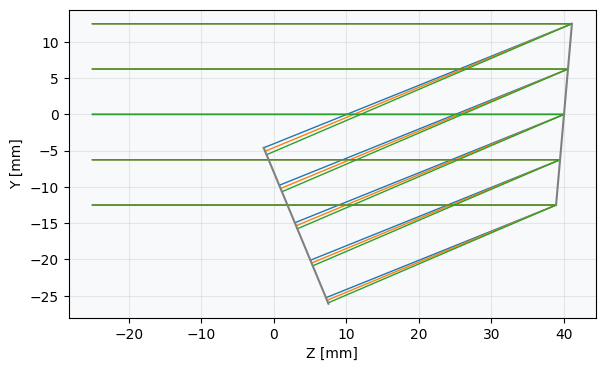

In [4]:
grating = optic.Optic()

alpha = 5*np.pi/180 # angle of incidence in radians
center_wl = 0.55 # center wavelength in microns
grating_order = 1
grating_period = 1 # grating period in microns

# Compute expected angle.

beta = np.arcsin(grating_order * center_wl / grating_period - np.sin(alpha))
exit_angle = alpha - beta
print(alpha*180/np.pi, beta*180/np.pi, (alpha + beta)*180/np.pi)

# define surfaces
grating.add_surface(index=0, radius=np.inf, thickness=np.inf)
grating.add_surface(index=1, z=0, is_stop=True)
grating.add_surface(index=2, z=40, rx=alpha,
                    material="mirror",
                    surface_type = "plane_grating",
                    grating_order = grating_order, 
                    grating_period = grating_period,
                    grating_orientation = 0*np.pi/180)

# If the program works, then the rays will be centered on this surface!
grating.add_surface(index=3, z=40 - 40*np.cos(exit_angle), 
                    y=40*np.sin(exit_angle), rx = exit_angle)

# define aperture
grating.set_aperture(aperture_type="EPD", value=25)

# define fields
grating.set_field_type(field_type="angle")
grating.add_field(y=0)

# define wavelengths
grating.add_wavelength(value=0.55, is_primary=True)

grating.draw(num_rays=5, wavelengths=[0.54, 0.55, 0.56])

# Example: A Czerny-Turner spectrograph

Reference: The Richardson Grating Handbook:

https://diverdi.colostate.edu/C431/experiments/time%20domain%20fluorescence/diffraction%20gratings/Richardson%20Gratings%20Handbook.pdf

Page 25 talks about a "constant deviation" monochromator. In most monochromators, *the optics are bolted down* and only the grating moves. Thus the angle between the incident and diffracted beams is constant. A spectrograph can be treated like a monochromator for this purpose by computing the angles for the wavelength at the center of the spectrum.

According to the Handbook, $2K$ is this deviation angle:

$2K = \alpha + \beta$ = constant

The *scan* angle is given as:

$2 \phi = \alpha - \beta$

In a monochromator, the value of $\phi = 0$ can be found at the "zero order" point where all wavelengths pass through the exit aperture.

Therefore,

$m \lambda = 2d \cos K \sin \phi$

alpha (incidence angle): -35.219275738423164
beta (exit angle): 55.21927573842317
alpha + beta (total angle): 20.000000000000004


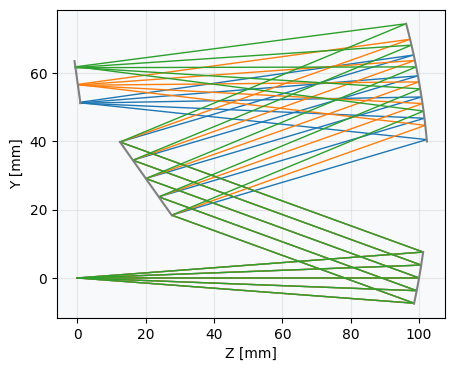

In [7]:
focal_length = 100
mirror_angle = 10*np.pi/180
K = 10*np.pi/180
center_wavelength = 0.55 # center wavelength in microns
grating_order = 1
grating_period = 1 # in wavenlength units
grating_setback = 80
phi = np.arcsin(grating_order*center_wavelength /2/ grating_period - np.cos(K))
alpha = K + phi
beta = K - phi
print("alpha (incidence angle):", alpha*180/np.pi)
print("beta (exit angle):", beta*180/np.pi)
print("alpha + beta (total angle):", (alpha + beta)*180/np.pi)

# Correct for sagittal focus

mirror_radius = focal_length/np.cos(mirror_angle)

ct = optic.Optic()
ct.add_surface(index=0, z=0)

# Czerny mirror

ct.add_surface(index=1, 
               z = focal_length,
               rx = mirror_angle,
               radius = -2*mirror_radius, 
               material="mirror", is_stop=True,
)

# Grating

y = grating_setback * np.tan(2*mirror_angle)

ct.add_surface(index=2,
               z=focal_length - grating_setback,
               y = y,
               surface_type="plane_grating",
               material="mirror",
               rx = alpha,
               grating_order=grating_order,
               grating_period=grating_period,
               grating_orientation=0*np.pi/180,
)

# Turner mirror

y = y + grating_setback * 2*np.tan(K)

ct.add_surface(index=3,
               z=focal_length,
               rx=-mirror_angle,
               radius = -2*mirror_radius,
               y= y,
               material="mirror",
)

# Exit surface. I added a bit of tilt by eye, to optimize the focus at the ends
# of the image. The focal plane is actually curved, with a large radius of curvature,
# but because it's an off axis system, the center of curvature is not at
# the center of the image. So a tilted plane is actually a chord of this curve.

ct.add_surface(index=4,
               z=0,
               y=y,
               rx = -8*np.pi/180,  # small tilt for exit surface
               material="mirror",
)

ct.set_aperture(aperture_type="EPD", value=15)
ct.set_field_type(field_type="angle")
ct.add_field(y=0)

ct.add_wavelength(value=center_wavelength, is_primary=True)
ct.draw(num_rays=5, wavelengths=[0.50, 0.55, 0.60])